![Práctica 5 - Librería SCIKIT-LEARN](img/cabecera-Scikit-learn.png)

Resuelto por: 

- Adrián Benítez Roldán
- Alejandro Montes Cantero

# Scikit-learn (parte 2).

En esta sesión vamos a ver algunos ejemplos de diversos algoritmos que contiene Scikit-learn. Importaremos primero las librerías comunes para la mayoría de los programas, incluida la librería `seaborn` que está basada en `matplotlib` y nos permite crear gráficas mas atractivas.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn

seaborn.set() #estilos para gráficas mas vistosos.

ModuleNotFoundError: No module named 'seaborn'

## Regresión lineal

La regresión lineal o ajuste lineal es un modelo matemático usado para aproximar la relación de dependencia entre una variable dependiente $Y$, las variables independientes $X_i$ y un error aleatorio. En resumen, nos permite **aproximar** el valor de $Y$ a partir de las características $X_i$.

El ejemplo más utilizado es el que aproxima el valor de $Y$ a partir de una única característica, ya que es muy fácil de representar en una gráfica. Para ver dicho ejemplo, vamos a crear un par de funciones que me genere de forma aleatoria los valores de $X$ e $Y$.

In [ ]:
def test_func(x, err=0.5):
    #Genera los valores de Y a partir de X con un error predefinido.
    y = 10 - 1. / (x + 0.1)
    if err > 0:
        y = np.random.normal(y, err)
    return y

def make_data(N=40, error=1.0, random_seed=1):
    # Genera un conjunto de datos aleatorios de X e y
    np.random.seed(1)
    X = np.random.random(N)[:,np.newaxis] #matriz de 1 columna
    y = test_func(X, error)
    
    return X, y

Vamos a crear un conjunto de datos con estas funciones y los mostramos en una gráfica.

In [ ]:
X, y = make_data(40, error=1)
plt.scatter(X.ravel(), y);

Esta representación se conoce comúnmente como *nube de puntos* y con la regresión lineal intentaremos encontrar la recta que más se aproxime a estos valores.

A continuación, vamos a entrenar el modelo de regresión lineal y crearemos un conjunto de test con 500 números en el rango [-0.1 , 1.1] para poder representar la recta que define dicho modelo.

In [ ]:
#Entrenar modelo de regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X, y)

#Crear datos de test
X_test = np.linspace(-0.1, 1.1, 500)[:, None] #Matriz de 1 columna
y_test = model.predict(X_test)

#Mostrar la nube de puntos y la recta del modelo junto con el error cuadrático medio (MSE).
plt.scatter(X.ravel(), y)
plt.plot(X_test.ravel(), y_test, 'g')
plt.title("MSE: {0:.3g}".format(mean_squared_error(model.predict(X), y)));

### Regresión polinomial.

Existen otras maneras de ajustar la nube de puntos, por ejemplo con una curva. A este ajuste se le suele denominar regresión polinomial.

Vamos a intentar crear un modelo que realice esta tarea utilizando la regresión lineal. Para ello debemos primero convertir cada variable $X$ en un conjunto de variables $X^0$, $X^1$, ... $X^n$, para que la regresión lineal ajuste los coeficientes de cada variable.

Para realizar esta tarea vamos a crear un nueva función que realice el preprocesado y la regresión en un único paso.

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def PolynomialRegression(n=2, **kwargs):
    return make_pipeline(
        PolynomialFeatures(n),
        LinearRegression(**kwargs)
    )

Ahora vamos a intentar ajustar la nube de puntos a una curva cuadrática.

In [ ]:
model = PolynomialRegression(2)
model.fit(X, y)
y_test = model.predict(X_test)

plt.scatter(X.ravel(), y)
plt.plot(X_test.ravel(), y_test,'g')
plt.title("MSE: {0:.3g}".format(mean_squared_error(model.predict(X), y)));

Como se puede comprobar esto reduce el error cuadrático medio (MSE) y se ajusta mucho mejor a los datos.

**¿Qué ocurriría si utilizásemos un polinomio de grado mucho mayor?**

In [ ]:
model = PolynomialRegression(30)
model.fit(X, y)
y_test = model.predict(X_test)

plt.scatter(X.ravel(), y)
plt.plot(X_test.ravel(), y_test, 'g')
plt.title("MSE: {0:.3g}".format(mean_squared_error(model.predict(X), y)))
plt.ylim(-4, 14);

Cuando incrementamos el grado del polinómio reducimos el error medio, pero se puede ver claramente que la curva está **sobre ajustada** ya que no refleja claramente la tendencia de la distribución de datos.

## Curvas de validación

Scikit-learn tiene herramientas para poder ajustar los parámetros de cualquier estimador o clasificador. La mas útil es la curva de validación (`validation_curve`). Esta utilidad realiza la validación cruzada de nuestro estimador utilizando además un rango de valores en el parámetro deseado.

Para entenderlo mejor veamos un ejemplo. Primero creamos un nuevo conjunto de datos con mas ejemplos:

In [ ]:
X, y = make_data(120, error=1.0)
plt.scatter(X, y);

A continuación creamos una función que dado un modelo, unos datos de test y los valores a predecir nos devuelva el error cuadrático medio.

In [ ]:
def rms_error(model, X, y):
    y_pred = model.predict(X)
    return np.sqrt(np.mean((y - y_pred) ** 2))

Por último utilizamos la herramienta `validation_curve` para obtener los errores medios para las curvas de distintos grados.

In [ ]:
from sklearn.model_selection import validation_curve

degree = np.arange(0, 18)
val_train, val_test = validation_curve(PolynomialRegression(), X, y,
                                       'polynomialfeatures__degree', degree, cv=7,
                                       scoring=rms_error)

NameError: name 'X' is not defined

Para facilitar el dibujo de la gráfica, creamos un función que pinte la línea de error y una sombra que represente la desviación estándar:

In [ ]:
def plot_with_err(x, data, **kwargs):
    mu, std = data.mean(1), data.std(1)
    lines = plt.plot(x, mu, '-', **kwargs)
    plt.fill_between(x, mu - std, mu + std, edgecolor='none',
                     facecolor=lines[0].get_color(), alpha=0.2)

Por último pintamos las curvas de error para el entrenamiento y el test realizado:

In [ ]:
plot_with_err(degree, val_train, label='training scores')
plot_with_err(degree, val_test, label='validation scores')
plt.xlabel('degree'); plt.ylabel('rms error')
plt.legend();

Como se puede observar en la gráfica a partir del grado 5 el conjunto de test genera mayor error que el de entrenamiento, por lo que su comportamiento no es robusto.

Por lo tanto, nos deberíamos decantar por utilizar un grado 4 o 5. En nuestro caso utilizaremos un grado 4 porque la desviación estandar es menor. 

In [ ]:
model = PolynomialRegression(4).fit(X, y)
plt.scatter(X, y)
plt.plot(X_test, model.predict(X_test), 'g');

## Reducción de la dimensionalidad (PCA)

Existen veces en que el número de características que utilizamos es demasiado grande, por lo que sería conveniente reducir o eliminar características que introducen ruido o que están correlacionadas.

La técnica mas utilizada es el **análisis de componentes principales** o **PCA** (de sus siglas en inglés), que consiste en:

> Buscar la proyección según la cual los datos queden mejor representados en términos de mínimos cuadrados. Esta convierte un conjunto de observaciones de variables posiblemente correlacionadas en un conjunto de valores de variables sin correlación lineal llamadas componentes principales. - [Wikipedia](https://es.wikipedia.org/wiki/An%C3%A1lisis_de_componentes_principales)

Este es un método no supervisado muy poderoso

Veamos un ejemplo de reducción características utilizando el *IRIS dataset* proporcionado por `scikit-learn`.


In [ ]:
from sklearn import neighbors, datasets
from sklearn.decomposition import PCA
import pylab as pl

#Cargar dataset.
iris = datasets.load_iris()
X, y = iris.data, iris.target

#Reducir dimensionalidad.
pca = PCA(n_components=2)
pca.fit(X)
X_reduced = pca.transform(X)
print("Tamaño del dataset original:", X.shape)
print("Tamaño del dataset reducido:", X_reduced.shape)

#Pintar en una gráfica las 2 dimensiones que han quedado.
pl.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='RdYlBu')

#Mostrar peso de cada característica en los 2 componentes.
print("Significado de los 2 componentes:")
for component in pca.components_:
    for value, name in zip(component, iris.feature_names):
        print("%+.3f x %s" % (value, name), end=' ')
    print()


## Agrupación de elementos (K-Means).

*K-Means* es un algoritmo para agrupación no supervisada, el cual encuentra grupos en los datos basándose en sus características (y no en las etiquetas).

Vamos a utilizar los datos anteriores para agruparlos y mostrarlos por colores según el grupo decidido por K-Means (y no por su categoría).

In [ ]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=3, random_state=0)
k_means.fit(X)
y_pred = k_means.predict(X)

pl.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_pred,
           cmap='RdYlBu');

Si comparamos esta gráfica con la anterior podemos ver que ha generado unos grupos muy similares a las clases de cada elemento.

Generemos ahora un nuevo conjunto de datos aleatorios para realizar la agrupación. Los mostraremos en una gráfica sin diferenciarlos por color, ya que los datos no pertenecen a ninguna clase en concreto (es un método no supervisado).

In [ ]:
from sklearn.datasets.samples_generator import make_blobs
X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], s=50);

A ojo, es relativamente fácil elegir ver que hay 4 grupos. Si agrupamos con K-Means y damos color a cada grupo, podemos ver que ejemplos ha incluido en cada grupo.

In [ ]:
from sklearn.cluster import KMeans
est = KMeans(4)  # 4 clusters
est.fit(X)
y_kmeans = est.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='rainbow');

## Preprocesado de los datos

El paquete `sklearn.preprocessing` contienen varias utilidades comunes para la transformación de los vectores de características en un representación mas adecuada para algunos modelos.

A continuación vamos a ver algunas de estas funciones.

### Escalado de datos.

La función `scale` permite escalar los datos de una matriz por columnas, de forma que la media sea 0 y la varianza 1.

In [ ]:
from sklearn import preprocessing
X = np.array([[ 1., -1.,  2.],
              [ 2.,  0.,  0.],
              [ 0.,  1., -1.]])

X_scaled = preprocessing.scale(X)

X_scaled                           

También se puede crear un modelo que realice el escalado de los datos de entrenamiento y que mantenga la información necesaria para poder realizar posteriormente el mismo escalado a los datos de test.

In [ ]:
scaler = preprocessing.StandardScaler().fit(X)

print("Modelo.............:", scaler)
print("Medias.............:", scaler.mean_)
print("Desviación estándar:", scaler.scale_)

scaler.transform([[-1.,  1., 0.]])                


También se puede hacer un escalado entre 0 y 1 utilizando la clase `MinMaxScaler`:

In [ ]:
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)
X_minmax

### Binarización de los datos

A veces es necesario pasar las características numéricas a valores lógicos utilizando un umbral. Para ello existe el modelo `Binarizer`:

In [ ]:
binarizer = preprocessing.Binarizer(threshold=1.1)
binarizer.transform(X)

### Codificación de datos categóricos.

A veces, las características no son valores contínuos, sino valores categóricos. Por ejemplo, una persona puede tener 3 caracteríscas:

* hombre o mujer.
* español, frances o itailano
* rubio, moreno, castaño o calvo

Cada característica puede ser codificada con un número entero, de manera que una persona `['hombre','español','castaño']` puede ser codificado como `[0,1,3]`.

Sin embargo, los modelos de scikit-learn esperan valores reales por lo que esta codificación no es correcta. Por lo que la solución mas sencilla sería convertir estos valores con un algoritmo del tipo *OneHotEncoder* que genera características binarias.

In [ ]:
enc = preprocessing.OneHotEncoder()
enc.fit([[0, 0, 3], [1, 1, 0], [0, 2, 1], [1, 0, 2]])  
enc.transform([[0, 1, 3]]).toarray()

Si los datos los tenemos en un diccionario podemos utilizar la clase `DicVectorized`:

In [ ]:
measurements = [
    {'city': 'Dubai', 'temperature': 33.},
    {'city': 'London', 'temperature': 12.},
    {'city': 'San Fransisco', 'temperature': 18.},
]

from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer()

vec.fit_transform(measurements).toarray()

Para saber a que corresponde cada columna:

In [ ]:
vec.get_feature_names()

# En resumen

Las librerías de scikit-learn contienen multitud de algoritmos/modelos para clasificación, regresión, agrupamiento, reducción de la dimensionalidad, validación y comparación de los modelos, e incluso para el preprocesado de los datos.

En la propia página web de scikit-learn puedes encontrar una imagen resumen de que algoritmos aplicar según lo que desees hacer y los datos que tengas:

![scikit-learn algorithm cheat sheet](http://scikit-learn.org/dev/_static/ml_map.png)

Fitting 7 folds for each of 60 candidates, totalling 420 fits


c:\Users\benro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
14 fits failed out of a total of 420.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\benro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\benro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\benro\AppDa

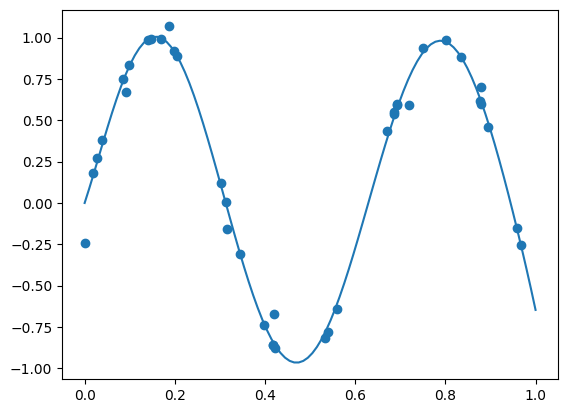

{'linear__fit_intercept': False, 'poly__degree': np.int64(8), 'poly__include_bias': False}
-0.016752325748042092


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

rng = np.random.RandomState(1)
X = np.sort(rng.rand(40, 1), axis=0)
y = np.sin((X * 10)).ravel()

y[::5] += 0.5 * (0.5 - rng.rand(8))

pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures(include_bias=True)),
    ('linear', LinearRegression(
        fit_intercept=True,
        copy_X=True,
        n_jobs=None
    ))
])

param_grid = {
    'poly__degree': np.arange(0, 15),
    'poly__include_bias': [True, False],
    'linear__fit_intercept': [True, False]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=7,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(X, y)

best_model = grid.best_estimator_

X_test = np.linspace(0, 1, 100)[:, None]

y_test = best_model.predict(X_test)

plt.scatter(X, y)
plt.plot(X_test, y_test)
plt.show()

print(grid.best_params_)
print(grid.best_score_)